# CADA - Model Benchmarking & Evaluation

This notebook provides a comparative evaluation between **Supervised Classification**, **Unsupervised Anomaly Detection**, and the **CADA Composite Risk Architecture**.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

# Add project root to sys.path
sys.path.insert(0, str(Path.cwd().parent))

from src.evaluation.benchmark import run_full_benchmark
from src.scoring.cada_scorer import CADACompositeScorer
from src.data.loader import load_motion_data
from src.data.preprocessor import MotionDataPreprocessor
from src.features.kinematics import KinematicFeatureExtractor

## 1. Execute Multi-Model Benchmark Suite

In [2]:
benchmark_results = run_full_benchmark()
df_bench = pd.DataFrame.from_dict(benchmark_results, orient='index')
display(df_bench[['precision', 'recall', 'f1_score', 'accuracy', 'roc_auc', 'pr_auc', 'spearman_correlation', 'latency_ms_per_sample']])


================== CADA BENCHMARK RESULTS ==================
                                 precision    recall  f1_score  accuracy   roc_auc    pr_auc  spearman_correlation        p_value  latency_ms_per_sample
Supervised_HistGradientBoosting   0.790387  0.727273  0.757518  0.877108  0.886713  0.835902              0.638934   0.000000e+00               0.003220
Supervised_RandomForest           0.731305  0.708845  0.719900  0.854410  0.912030  0.820415              0.683334   0.000000e+00               0.015648
Unsupervised_IsolationForest      0.554348  0.375921  0.448023  0.755512  0.759831  0.546148              0.415007  1.088089e-128               0.006484
Unsupervised_OneClassSVM          0.400000  0.493857  0.442001  0.670882  0.657853  0.500011              0.199738   4.042094e-29               0.012414
CADA_Composite_Architecture       0.795164  0.686732  0.736981  0.870623  0.896460  0.791195              0.601971  1.654449e-303               0.015902

Saved benchmark rep

,precision,recall,f1_score,accuracy,roc_auc,pr_auc,spearman_correlation,latency_ms_per_sample
Supervised_HistGradientBoosting,0.790387,0.727273,0.757518,0.877108,0.886713,0.835902,0.638934,0.003220
Supervised_RandomForest,0.731305,0.708845,0.719900,0.854410,0.912030,0.820415,0.683334,0.015648
Unsupervised_IsolationForest,0.554348,0.375921,0.448023,0.755512,0.759831,0.546148,0.415007,0.006484
Unsupervised_OneClassSVM,0.400000,0.493857,0.442001,0.670882,0.657853,0.500011,0.199738,0.012414
CADA_Composite_Architecture,0.795164,0.686732,0.736981,0.870623,0.896460,0.791195,0.601971,0.015902


## 2. Load Scored Test Telemetry & Visualizations

In [3]:
# Load test data
df_test = load_motion_data('../data/raw/test_motion_data.csv', require_target=True)
preproc = MotionDataPreprocessor()
kinematics = KinematicFeatureExtractor()
df_test_feat = kinematics.fit_transform(preproc.fit_transform(df_test))

# Load trained CADA scorer
scorer = CADACompositeScorer.load('../models/cada_model_bundle.joblib')
df_scored = scorer.score_batch(df_test_feat)
df_scored.head()

,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,AccMag,GyroMag,AccXY,GyroXY,...,AccXY_energy_40,AccXY_ewm_40,AccXY_dev_40,Class,Timestamp,Iso_Risk,Stat_Risk,Temporal_Risk,CADA_Score,Risk_Tier
0,0.758194,-0.217791,0.457263,0.000000,0.000000,0.000000,0.911801,0.000000,0.788854,0.000000,...,0.622291,0.788854,0.000000,AGGRESSIVE,818922,44.854526,50.475244,0.000000,14.309188,NORMAL
1,0.667560,-0.038610,0.231416,-0.054367,-0.007712,0.225257,0.707588,0.231853,0.668676,0.054911,...,0.534709,0.727263,-0.060089,AGGRESSIVE,818923,50.656317,50.875308,6.301693,16.178304,NORMAL
2,2.724449,-7.584121,2.390926,0.023824,0.013668,-0.038026,8.405834,0.046908,8.058630,0.027466,...,22.003643,3.294234,4.886577,AGGRESSIVE,818923,91.618054,100.000000,100.000000,98.692494,CRITICAL
3,2.330950,-7.621754,2.529024,0.056810,-0.180587,-0.052076,8.361843,0.196344,7.970223,0.189312,...,32.383847,4.552330,3.598628,AGGRESSIVE,818924,87.576380,100.000000,77.670652,94.734016,CRITICAL
4,2.847215,-6.755621,2.224640,-0.031765,-0.035201,0.035277,7.661206,0.059098,7.331102,0.047414,...,36.656088,5.165013,2.367605,AGGRESSIVE,818924,85.677496,100.000000,84.013455,95.398049,CRITICAL


## 3. CADA Risk Score Distribution across Driving Classes

/tmp/ipykernel_25910/3602480711.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_scored, x='Class', y='CADA_Score', palette='Set2', inner='quartile')


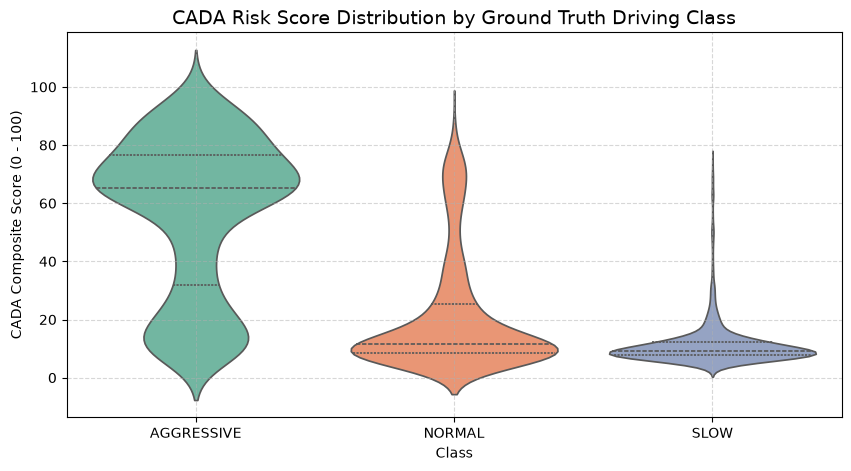

In [4]:
plt.figure(figsize=(10, 5))
sns.violinplot(data=df_scored, x='Class', y='CADA_Score', palette='Set2', inner='quartile')
plt.title('CADA Risk Score Distribution by Ground Truth Driving Class', fontsize=14)
plt.ylabel('CADA Composite Score (0 - 100)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4. Risk Component Attribution (Iso vs Stat vs Temporal)

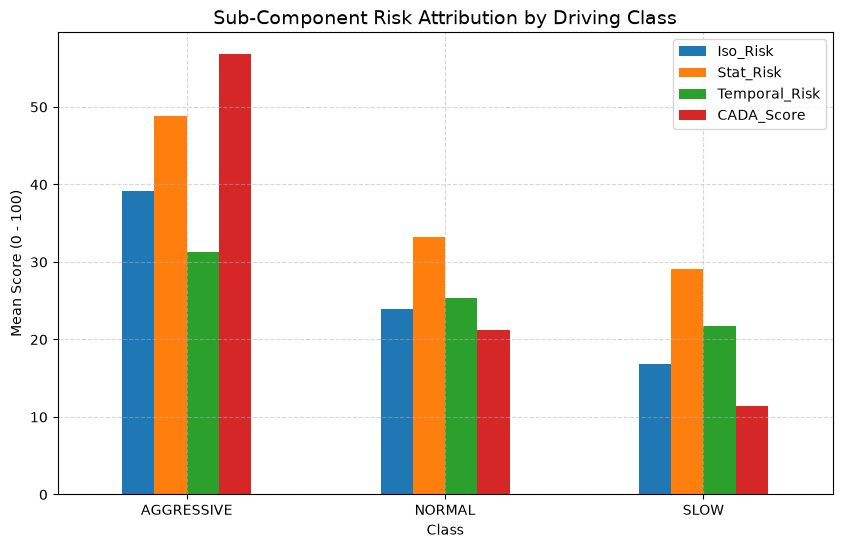

In [5]:
comp_means = df_scored.groupby('Class')[['Iso_Risk', 'Stat_Risk', 'Temporal_Risk', 'CADA_Score']].mean()
comp_means.plot(kind='bar', figsize=(10, 6))
plt.title('Sub-Component Risk Attribution by Driving Class', fontsize=14)
plt.ylabel('Mean Score (0 - 100)')
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()